In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import poisson

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("C:/Users/Joan/Desktop/TFG/db/SP1.csv")

In [3]:
print(df.shape)

df.head()

(380, 119)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,BFH,BFD,BFA,PSH,PSD,PSA,WHH,WHD,WHA,1XBH,1XBD,1XBA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,BFEH,BFED,BFEA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,BFE>2.5,BFE<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,BFEAHH,BFEAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,BFCH,BFCD,BFCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,1XBCH,1XBCD,1XBCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,BFEC>2.5,BFEC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,SP1,15/08/2024,18:00,Ath Bilbao,Getafe,1,1,D,1,0,H,7,9,4,2,15,12,5,6,4,1,0,0,1.48,4.00,8.00,1.44,4.20,7.75,1.53,3.9,7.50,1.48,4.12,8.24,1.44,4.0,8.50,1.52,4.16,8.50,1.58,4.20,8.90,1.51,4.04,7.61,1.57,4.0,8.20,2.20,1.67,2.34,1.65,2.34,1.71,2.24,1.67,2.30,1.76,-1.00,1.84,2.06,1.86,2.05,2.01,2.12,1.90,1.96,2.06,1.92,1.57,3.6,7.0,1.60,3.6,6.5,1.57,3.50,7.00,1.61,3.71,7.18,1.60,3.50,7.0,1.61,3.65,7.40,1.63,3.82,7.50,1.59,3.63,6.96,1.63,3.75,8.0,2.63,1.50,2.61,1.54,2.66,1.59,2.51,1.54,2.68,1.58,-1.00,2.08,1.73,2.17,1.76,2.19,1.82,2.12,1.77,2.19,1.82
1,SP1,15/08/2024,20:30,Betis,Girona,1,1,D,1,0,H,19,13,4,2,11,7,4,4,2,0,0,0,2.35,3.40,3.00,2.40,3.25,2.95,2.40,3.4,3.00,2.41,3.42,3.07,2.40,3.3,3.00,2.46,3.47,3.12,2.46,3.47,3.12,2.40,3.38,3.02,2.48,3.5,3.20,1.97,1.93,1.94,1.94,1.98,1.99,1.93,1.90,2.02,1.96,-0.25,2.06,1.84,2.08,1.84,2.09,1.87,2.04,1.81,2.12,1.88,2.30,3.4,3.1,2.35,3.3,3.0,2.30,3.25,3.10,2.35,3.43,3.21,2.40,3.20,3.1,2.34,3.47,3.16,2.50,3.47,3.21,2.35,3.37,3.10,2.42,3.45,3.3,1.95,1.95,1.94,1.96,2.00,2.00,1.94,1.89,2.02,1.96,-0.25,2.01,1.89,2.03,1.89,2.10,1.94,2.01,1.85,2.08,1.90
2,SP1,16/08/2024,18:00,Celta,Alaves,2,1,H,0,1,A,6,10,4,2,8,23,3,3,3,2,0,0,2.00,3.20,4.10,2.05,3.30,3.80,2.00,3.3,4.10,2.05,3.37,4.12,2.00,3.3,4.00,2.09,3.41,4.11,2.09,3.41,4.20,2.03,3.32,4.02,2.10,3.4,4.20,2.20,1.67,2.31,1.68,2.34,1.71,2.25,1.67,2.38,1.71,-0.50,2.06,1.87,2.06,1.88,2.07,1.88,2.03,1.85,2.10,1.89,2.10,3.1,3.9,2.05,3.2,3.8,2.05,3.10,3.75,2.15,3.27,3.89,2.05,3.25,3.9,2.11,3.18,4.14,2.15,3.34,4.14,2.10,3.24,3.86,2.16,3.35,4.0,2.30,1.62,2.40,1.63,2.40,1.67,2.31,1.63,2.44,1.68,-0.25,1.82,2.11,1.83,2.10,1.84,2.12,1.79,2.08,1.85,2.14
3,SP1,16/08/2024,20:30,Las Palmas,Sevilla,2,2,D,1,1,D,13,16,5,5,12,13,6,3,0,0,0,0,2.80,3.25,2.63,2.85,3.20,2.55,2.80,3.1,2.63,2.87,3.23,2.71,2.88,3.1,2.62,2.92,3.31,2.70,2.92,3.31,2.75,2.83,3.21,2.65,2.96,3.3,2.78,2.20,1.67,2.22,1.73,2.25,1.75,2.18,1.71,2.28,1.76,0.00,2.03,1.90,2.02,1.90,2.04,1.91,2.01,1.88,2.06,1.93,2.55,3.3,2.8,2.65,3.1,2.8,2.55,3.00,2.70,2.65,3.25,2.93,2.70,3.10,2.8,2.71,3.37,2.74,2.78,3.37,2.95,2.66,3.19,2.83,2.72,3.30,3.0,2.10,1.73,2.17,1.76,2.20,1.79,2.14,1.73,2.22,1.81,0.00,1.86,2.07,1.87,2.07,1.89,2.11,1.86,2.03,1.90,2.09
4,SP1,17/08/2024,18:00,Osasuna,Leganes,1,1,D,0,1,A,16,10,5,4,14,12,6,4,3,2,0,0,1.85,3.30,4.50,1.82,3.40,4.60,1.90,3.4,4.60,1.89,3.47,4.57,1.85,3.4,4.60,1.92,3.57,4.67,1.93,3.57,4.70,1.88,3.44,4.48,1.93,3.5,4.90,2.30,1.62,2.37,1.63,2.45,1.68,2.34,1.62,2.52,1.64,-0.50,1.91,2.02,1.90,2.00,1.93,2.04,1.88,1.98,1.93,2.05,1.83,3.1,5.0,1.85,3.2,5.0,1.80,3.10,4.75,1.88,3.28,5.19,1.85,3.25,4.8,1.86,3.29,5.32,1.91,3.41,5.32,1.87,3.26,4.92,1.91,3.40,5.3,2.75,1.44,2.90,1.47,2.90,1.54,2.69,1.48,2.96,1.50,-0.50,1.88,2.05,1.88,2.04,1.91,2.06,1.87,2.00,1.94,2.05


In [4]:
cols = [
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
    "AvgH",
    "AvgD",
    "AvgA"
]

df = df[cols].copy()

In [5]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

In [6]:
df["PH"] = 1 / df["AvgH"]
df["PD"] = 1 / df["AvgD"]
df["PA"] = 1 / df["AvgA"]

In [7]:
df["Overround"] = df["PH"] + df["PD"] + df["PA"]

df["Margin"] = df["Overround"] - 1

In [8]:
print(df["Margin"].describe())

count    380.000000
mean       0.047491
std        0.003463
min        0.038521
25%        0.044808
50%        0.047716
75%        0.050114
max        0.059866
Name: Margin, dtype: float64


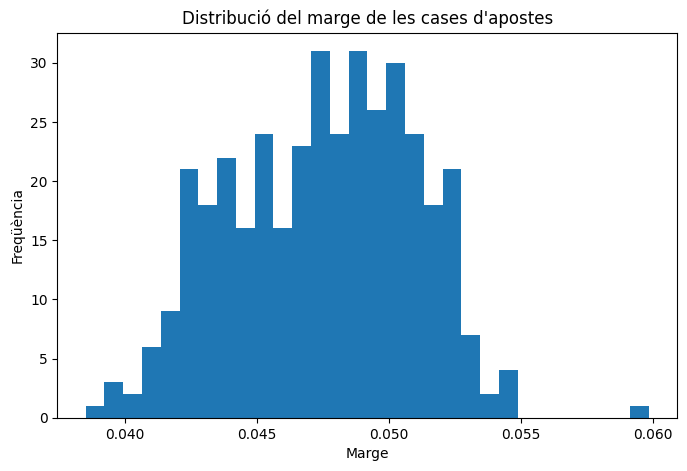

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Margin"], bins=30)

plt.xlabel("Marge")
plt.ylabel("Freqüència")
plt.title("Distribució del marge de les cases d'apostes")

plt.show()

In [10]:
df["HomeWin"] = (df["FTR"] == "H").astype(int)
df["Draw"] = (df["FTR"] == "D").astype(int)
df["AwayWin"] = (df["FTR"] == "A").astype(int)

In [11]:
bins = np.arange(0, 1.05, 0.05)

df["PH_bin"] = pd.cut(df["PH"], bins)

In [12]:
calibration = df.groupby("PH_bin").agg(
    predicted=("PH", "mean"),
    actual=("HomeWin", "mean"),
    count=("HomeWin", "size")
)

print(calibration)

             predicted    actual  count
PH_bin                                 
(0.0, 0.05]        NaN       NaN      0
(0.05, 0.1]   0.086242  0.000000      3
(0.1, 0.15]   0.124462  0.250000      8
(0.15, 0.2]   0.178752  0.111111     18
(0.2, 0.25]   0.226792  0.173913     23
(0.25, 0.3]   0.274819  0.058824     17
(0.3, 0.35]   0.324686  0.355556     45
(0.35, 0.4]   0.374209  0.290323     31
(0.4, 0.45]   0.424319  0.434783     46
(0.45, 0.5]   0.476652  0.375000     32
(0.5, 0.55]   0.524513  0.500000     34
(0.55, 0.6]   0.577241  0.538462     39
(0.6, 0.65]   0.622264  0.631579     19
(0.65, 0.7]   0.675515  0.600000     10
(0.7, 0.75]   0.727167  0.809524     21
(0.75, 0.8]   0.775418  0.866667     15
(0.8, 0.85]   0.827349  1.000000     10
(0.85, 0.9]   0.871423  0.777778      9
(0.9, 0.95]        NaN       NaN      0
(0.95, 1.0]        NaN       NaN      0


C:\Users\Joan\AppData\Local\Temp\ipykernel_27100\2169304054.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df.groupby("PH_bin").agg(


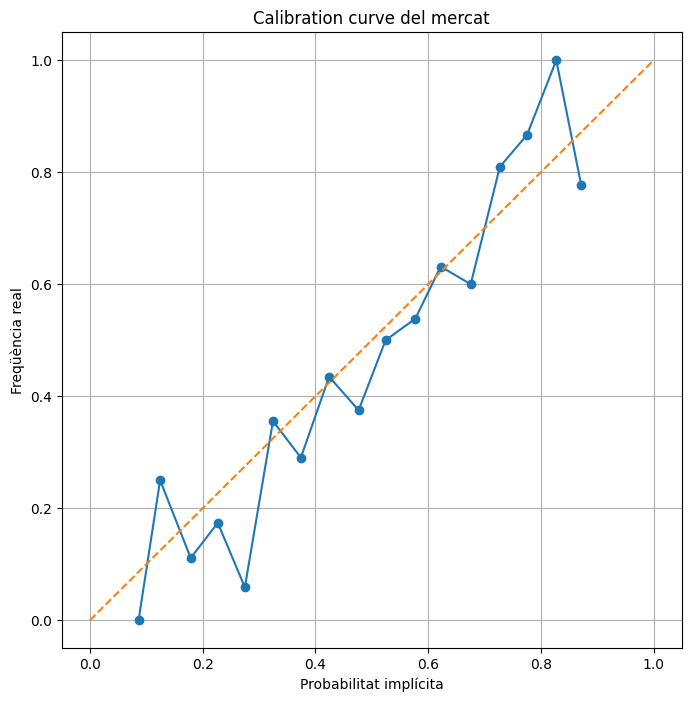

In [13]:
plt.figure(figsize=(8,8))

plt.plot(
    calibration["predicted"],
    calibration["actual"],
    marker="o"
)

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("Probabilitat implícita")
plt.ylabel("Freqüència real")

plt.title("Calibration curve del mercat")

plt.grid()

plt.show()

In [14]:
home_goals_avg = df["FTHG"].mean()
away_goals_avg = df["FTAG"].mean()

print("Mitjana gols local:", home_goals_avg)
print("Mitjana gols visitant:", away_goals_avg)

Mitjana gols local: 1.4526315789473685
Mitjana gols visitant: 1.1657894736842105


In [15]:
home_attack = df.groupby("HomeTeam")["FTHG"].mean() / home_goals_avg
home_defense = df.groupby("HomeTeam")["FTAG"].mean() / away_goals_avg
away_attack = df.groupby("AwayTeam")["FTAG"].mean() / away_goals_avg
away_defense = df.groupby("AwayTeam")["FTHG"].mean() / home_goals_avg

In [16]:
def expected_goals(home_team, away_team):

    lambda_home = (
        home_attack[home_team]
        * away_defense[away_team]
        * home_goals_avg
    )

    lambda_away = (
        away_attack[away_team]
        * home_defense[home_team]
        * away_goals_avg
    )

    return lambda_home, lambda_away

In [17]:
Equip1= "Barcelona"
Equip2= "Girona"

In [18]:
lambda_home, lambda_away = expected_goals(
    Equip1,
    Equip2
)

print(lambda_home, lambda_away)

2.974828375286041 0.8078887964833076


In [19]:
def score_matrix(home_team, away_team, max_goals=8):

    lambda_home, lambda_away = expected_goals(
        home_team,
        away_team
    )

    matrix = np.zeros((max_goals+1, max_goals+1))

    for home_goals in range(max_goals+1):
        for away_goals in range(max_goals+1):

            p_home = poisson.pmf(home_goals, lambda_home)
            p_away = poisson.pmf(away_goals, lambda_away)

            matrix[home_goals, away_goals] = (
                p_home * p_away
            )

    return matrix

In [20]:
matrix = score_matrix(
    Equip1,
    Equip2
)

print(matrix)

[[2.27607624e-02 1.83881650e-02 7.42779623e-03 2.00027779e-03
  4.04000503e-04 6.52774961e-05 8.78949296e-06 1.01441898e-06
  1.02442216e-07]
 [6.77093619e-02 5.47016349e-02 2.20964190e-02 5.95048312e-03
  1.20183216e-03 1.94189348e-04 2.61472331e-05 3.01772238e-06
  3.04748012e-07]
 [1.00711866e-01 8.13639878e-02 3.28665271e-02 8.85083301e-03
  1.78762221e-03 2.88839991e-04 3.88917654e-05 4.48860308e-06
  4.53286517e-07]
 [9.98668384e-02 8.06812999e-02 3.25907591e-02 8.77656973e-03
  1.77262309e-03 2.86416467e-04 3.85654424e-05 4.45094127e-06
  4.49483198e-07]
 [7.42716762e-02 6.00032551e-02 2.42379788e-02 6.52719717e-03
  1.31831237e-03 2.13009958e-04 2.86813931e-05 3.31019659e-06
  3.34283843e-07]
 [4.41890980e-02 3.56998772e-02 1.44207654e-02 3.88345827e-03
  7.84350607e-04 1.26733614e-04 1.70644444e-05 1.96945335e-06
  1.98887412e-07]
 [2.19091637e-02 1.77001679e-02 7.14988368e-03 1.92543697e-03
  3.88884740e-04 6.28351249e-05 8.46063224e-06 9.76464286e-07
  9.86093196e-08]
 [9.31

In [21]:
matrix.sum()

np.float64(0.9963965039521631)

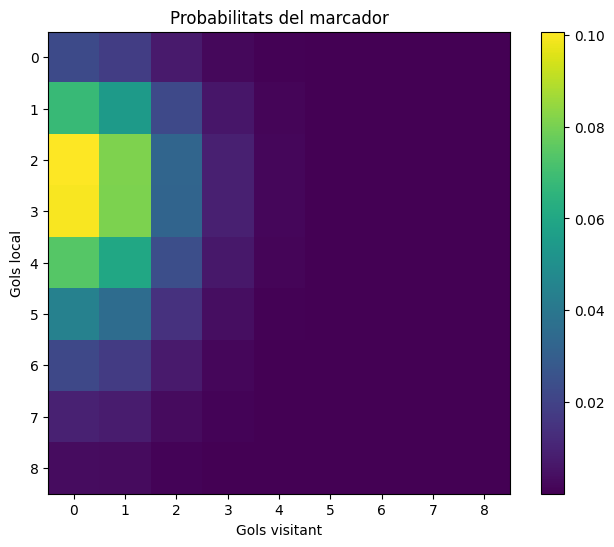

In [22]:
plt.figure(figsize=(8,6))

plt.imshow(matrix)

plt.colorbar()

plt.xlabel("Gols visitant")
plt.ylabel("Gols local")

plt.title("Probabilitats del marcador")

plt.show()

In [23]:
def match_outcome_probabilities(home_team, away_team):

    matrix = score_matrix(home_team, away_team)

    home_win = 0
    draw = 0
    away_win = 0

    rows, cols = matrix.shape

    for i in range(rows):
        for j in range(cols):

            if i > j:
                home_win += matrix[i, j]

            elif i == j:
                draw += matrix[i, j]

            else:
                away_win += matrix[i, j]

    return home_win, draw, away_win

In [24]:
phome, pdraw, paway = match_outcome_probabilities(
    Equip1,
    Equip2
)

print("Home Win:", phome)
print("Draw:", pdraw)
print("Away Win:", paway)

print("Total:", phome + pdraw + paway)

Home Win: 0.8047299360832159
Draw: 0.12055943133203113
Away Win: 0.07110713653691614
Total: 0.9963965039521632


In [25]:
match = df[
    (df["HomeTeam"] == Equip1) &
    (df["AwayTeam"] == Equip2)
].iloc[0]

match

Date          30/03/2025
HomeTeam       Barcelona
AwayTeam          Girona
FTHG                   4
FTAG                   1
FTR                    H
AvgH                1.24
AvgD                6.72
AvgA               10.69
PH              0.806452
PD               0.14881
PA              0.093545
Overround       1.048807
Margin          0.048807
HomeWin                1
Draw                   0
AwayWin                0
PH_bin       (0.8, 0.85]
Name: 284, dtype: object

In [26]:
book_ph = float(1 / match["AvgH"])
book_pd = float(1 / match["AvgD"])
book_pa = float(1 / match["AvgA"])

normalization = book_ph + book_pd + book_pa

book_ph /= normalization
book_pd /= normalization
book_pa /= normalization

print(book_ph, book_pd, book_pa)

0.7689231599183088 0.14188463069921176 0.08919220938247924


In [27]:
comparison = pd.DataFrame(
    {
        "Model": [phome, pdraw, paway],
        "Bookmaker": [book_ph, book_pd, book_pa]
    },
    index=["Home", "Draw", "Away"]
)

comparison

,Model,Bookmaker
Home,0.804730,0.768923
Draw,0.120559,0.141885
Away,0.071107,0.089192


In [28]:
def model_probabilities(row):

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    p_home, p_draw, p_away = match_outcome_probabilities(
        home,
        away
    )

    return pd.Series([p_home, p_draw, p_away])

In [29]:
df[["ModelH", "ModelD", "ModelA"]] = df.apply(
    model_probabilities,
    axis=1
)

In [30]:
df["BookH"] = 1 / df["AvgH"]
df["BookD"] = 1 / df["AvgD"]
df["BookA"] = 1 / df["AvgA"]

normalization = (
    df["BookH"] +
    df["BookD"] +
    df["BookA"]
)

df["BookH"] /= normalization
df["BookD"] /= normalization
df["BookA"] /= normalization

In [31]:
df["RealH"] = (df["FTR"] == "H").astype(int)
df["RealD"] = (df["FTR"] == "D").astype(int)
df["RealA"] = (df["FTR"] == "A").astype(int)

In [32]:
model_brier = np.mean(

    (df["ModelH"] - df["RealH"])**2 +
    (df["ModelD"] - df["RealD"])**2 +
    (df["ModelA"] - df["RealA"])**2

)

print("Model Brier Score:", model_brier)

Model Brier Score: 0.5458767355237854


In [33]:
book_brier = np.mean(

    (df["BookH"] - df["RealH"])**2 +
    (df["BookD"] - df["RealD"])**2 +
    (df["BookA"] - df["RealA"])**2

)

print("Bookmaker Brier Score:", book_brier)

Bookmaker Brier Score: 0.5639079805601994


In [34]:
df["ValueH"] = df["ModelH"] > df["BookH"]
df["ValueD"] = df["ModelD"] > df["BookD"]
df["ValueA"] = df["ModelA"] > df["BookA"]

In [35]:
df["ProfitH"] = np.where(

    df["ValueH"],

    np.where(
        df["FTR"] == "H",
        df["AvgH"] - 1,
        -1
    ),

    0
)

In [36]:
df["ProfitD"] = np.where(

    df["ValueD"],

    np.where(
        df["FTR"] == "D",
        df["AvgD"] - 1,
        -1
    ),

    0
)

In [37]:
df["ProfitA"] = np.where(

    df["ValueA"],

    np.where(
        df["FTR"] == "A",
        df["AvgA"] - 1,
        -1
    ),

    0
)

In [38]:
df["TotalProfit"] = (
    df["ProfitH"] +
    df["ProfitD"] +
    df["ProfitA"]
)

In [39]:
total_profit = df["TotalProfit"].sum()

total_bets = (
    df["ValueH"].sum() +
    df["ValueD"].sum() +
    df["ValueA"].sum()
)

roi = total_profit / total_bets

print("Total bets:", total_bets)
print("Total profit:", total_profit)
print("ROI:", roi)

Total bets: 523
Total profit: 51.03
ROI: 0.0975717017208413


In [40]:
def kelly_fraction(probability, odds):

    b = odds - 1

    f = (b * probability - (1 - probability)) / b

    return max(f, 0)

In [41]:
bankroll = 100

history = [bankroll]

for _, row in df.iterrows():

    bets = []

    if row["ValueH"]:

        bets.append(
            (
                row["ModelH"],
                row["AvgH"],
                row["FTR"] == "H"
            )
        )

    if row["ValueD"]:

        bets.append(
            (
                row["ModelD"],
                row["AvgD"],
                row["FTR"] == "D"
            )
        )

    if row["ValueA"]:

        bets.append(
            (
                row["ModelA"],
                row["AvgA"],
                row["FTR"] == "A"
            )
        )

    for probability, odds, won in bets:

        f = kelly_fraction(
            probability,
            odds
        )

        stake = bankroll * f

        if won:

            bankroll += stake * (odds - 1)

        else:

            bankroll -= stake

    history.append(bankroll)

In [42]:
print(bankroll)

262143.28022140928


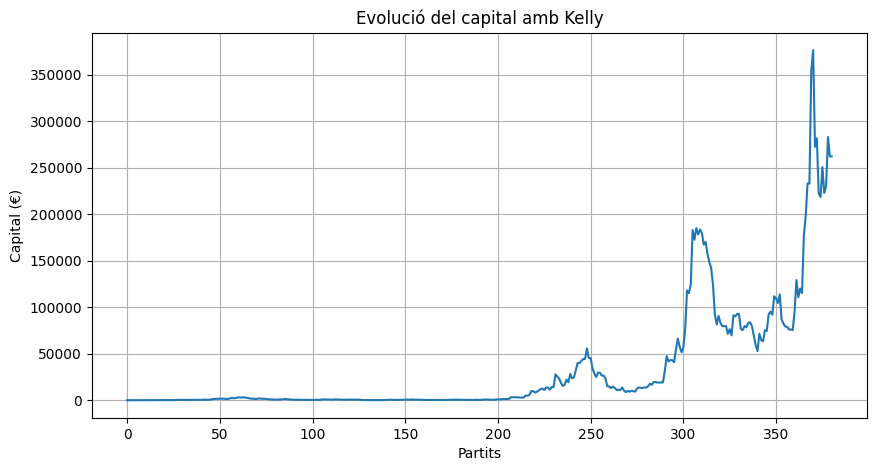

In [43]:
plt.figure(figsize=(10,5))

plt.plot(history)

plt.xlabel("Partits")
plt.ylabel("Capital (€)")
plt.title("Evolució del capital amb Kelly")

plt.grid()

plt.show()

In [44]:
home_attack = df.groupby("HomeTeam")["FTHG"].mean()

In [45]:
print("Model Brier:", model_brier)
print("Bookmaker Brier:", book_brier)

print("ROI:", roi)

print("Capital Kelly final:", bankroll)

Model Brier: 0.5458767355237854
Bookmaker Brier: 0.5639079805601994
ROI: 0.0975717017208413
Capital Kelly final: 262143.28022140928


Aquest model utilitza informació de tota la temporada i per tant no és adequat com a model predictiu (Leakage). Els resultats s'utilitzen únicament com a referència teòrica i punt de partida per al desenvolupament del model walk-forward.